#  DistilBERT Emotion Classification
**Model:** `distilbert-base-uncased`  
**Task:** 6-class tweet emotion detection  
**Dataset:** Kaggle Emotion Dataset  
---
### Pipeline Overview
```
Raw CSV → Language Filter → Augment → Clean → Tokenize → Fine-tune DistilBERT → Evaluate
```


##  1. Setup & Imports


In [ ]:
!pip install -q langdetect transformers[torch] datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 52.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, re, random, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_scheduler
)
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from nltk.corpus import wordnet
from langdetect import detect
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
# ── Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")


 Device: cuda


##  2. Load Dataset


In [ ]:
# Uncomment to upload in Colab:
# from google.colab import files
# files.upload()
df = pd.read_csv('emotion_dataset_raw.csv')
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()


Shape   : (34792, 2)
Columns : ['Emotion', 'Text']


,Emotion,Text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


##  3. Exploratory Data Analysis


In [ ]:
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nLabel distribution:\n{df['Emotion'].value_counts()}")


Null values:
Emotion    0
Text       0
dtype: int64
Label distribution:
Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64


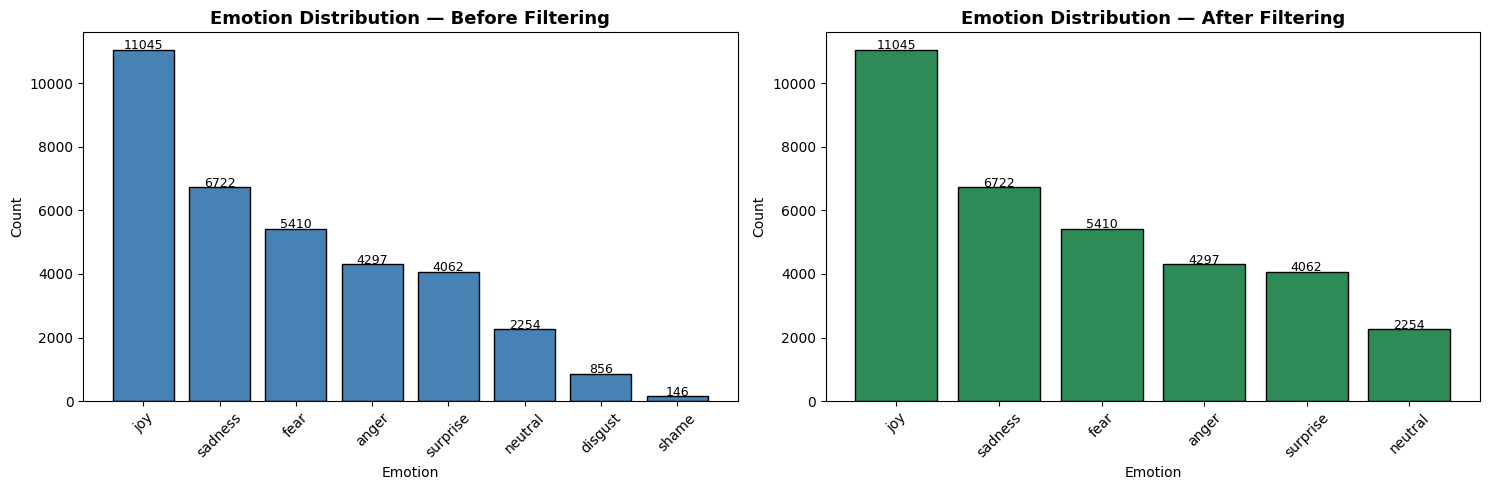

Remaining classes: ['neutral', 'joy', 'sadness', 'fear', 'surprise', 'anger']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Before filtering
counts_before = df['Emotion'].value_counts()
axes[0].bar(counts_before.index, counts_before.values, color='steelblue', edgecolor='black')
axes[0].set_title('Emotion Distribution — Before Filtering', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)
# Remove low-frequency / irrelevant classes
REMOVE_CLASSES = ['shame', 'disgust']
df = df[~df['Emotion'].isin(REMOVE_CLASSES)].reset_index(drop=True)
counts_after = df['Emotion'].value_counts()
axes[1].bar(counts_after.index, counts_after.values, color='seagreen', edgecolor='black')
axes[1].set_title('Emotion Distribution — After Filtering', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nRemaining classes: {df['Emotion'].unique().tolist()}")


##  4. Language Filtering (English Only)


In [ ]:
def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False
df['is_english'] = df['Text'].apply(is_english)
non_english_count = (~df['is_english']).sum()
print(f"Non-English tweets found : {non_english_count}")
df = df[df['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print(f"After filtering          : {len(df)} samples")
print(f"\nLabel distribution:\n{df['Emotion'].value_counts()}")


Non-English tweets found : 2886
After filtering          : 30904 samples
Label distribution:
Emotion
joy         10605
sadness      6403
fear         5111
anger        4165
surprise     3260
neutral      1360
Name: count, dtype: int64


##  5. Data Augmentation
We balance all emotion classes to **5,000 samples** each using two NLP augmentation strategies:
- **Synonym Replacement** — swap random words with WordNet synonyms
- **Random Deletion** — randomly drop words with probability `p=0.15`


In [ ]:
TARGET = 5000
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace('_', ' ')
            if candidate.lower() != word.lower():
                synonyms.add(candidate)
    return list(synonyms)
def synonym_replacement(text, n=2):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([w for w in words if get_synonyms(w)]))
    random.shuffle(random_word_list)
    for word in random_word_list[:n]:
        synonyms = get_synonyms(word)
        if synonyms:
            new_words = [random.choice(synonyms) if w == word else w for w in new_words]
    return ' '.join(new_words)
def random_deletion(text, p=0.15):
    words = text.split()
    if len(words) == 1:
        return text
    return ' '.join([w for w in words if random.random() > p])
def augment(text):
    return synonym_replacement(text) if random.random() < 0.5 else random_deletion(text)
augmented_rows = []
for emotion in df['Emotion'].unique():
    subset = df[df['Emotion'] == emotion]
    current = len(subset)
    if current < TARGET:
        needed = TARGET - current
        samples = subset.sample(n=needed, replace=True, random_state=SEED).copy()
        samples['Text'] = samples['Text'].apply(augment)
        augmented_rows.append(samples)
        print(f"  {emotion:<12} {current:>5} → {current + needed}")
    else:
        print(f"  {emotion:<12} {current:>5}  (no augmentation needed)")
df_aug = pd.concat([df] + augmented_rows, ignore_index=True)
df_aug = df_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"\nFinal distribution:\n{df_aug['Emotion'].value_counts()}")
print(f"Total samples: {len(df_aug)}")


  joy          10605  (no augmentation needed)
  sadness       6403  (no augmentation needed)
  fear          5111  (no augmentation needed)
  anger         4165 → 5000
  surprise      3260 → 5000
  neutral       1360 → 5000
Final distribution:
Emotion
joy         10605
sadness      6403
fear         5111
neutral      5000
surprise     5000
anger        5000
Name: count, dtype: int64
Total samples: 37119


##  6. Text Cleaning


In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'@\w+', '', text)           # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text
df_aug['clean_text'] = df_aug['Text'].apply(clean_text)
before = len(df_aug)
df_aug = df_aug[df_aug['clean_text'].str.strip() != ''].reset_index(drop=True)
df_aug = df_aug[df_aug['clean_text'].str.split().apply(len) > 1].reset_index(drop=True)
print(f"Removed {before - len(df_aug)} degenerate rows.")
print(f"Clean dataset size: {len(df_aug)}")
df_aug[['Text', 'clean_text', 'Emotion']].head()


Removed 97 degenerate rows.
Clean dataset size: 37022


,Text,clean_text,Emotion
0,When a thief broke into my house at night.,When a thief broke into my house at night.,fear
1,It must be locked .,It must be locked .,neutral
2,The people on my corridor accumulate into one ...,The people on my corridor accumulate into one ...,joy
3,@unicornmagic1 @Unicornmagic2 well now ht I kn...,"well now ht I know where you two are going, le...",surprise
4,My girlfriend started singing (she cannot sing...,My girlfriend started singing (she cannot sing...,anger


## ️ 7. Label Encoding & Train / Val / Test Split


In [ ]:
le = LabelEncoder()
df_aug['label'] = le.fit_transform(df_aug['Emotion'])
NUM_CLASSES = len(le.classes_)
print("Label mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} → {cls}")


Label mapping:
  0 → anger
  1 → fear
  2 → joy
  3 → neutral
  4 → sadness
  5 → surprise


In [ ]:
# 70 / 15 / 15 stratified split
X = df_aug['clean_text'].values
y = df_aug['label'].values
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print(f"Train : {len(X_train):>6} samples")
print(f"Val   : {len(X_val):>6} samples")
print(f"Test  : {len(X_test):>6} samples")


Train :  25915 samples
Val   :   5553 samples
Test  :   5554 samples


##  8. Tokenization


In [ ]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)
print(f"Token tensor shape : {train_enc['input_ids'].shape}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token tensor shape : torch.Size([25915, 128])


## ️ 9. Dataset & DataLoaders


In [ ]:
BATCH_SIZE = 32
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
train_dataset = EmotionDataset(train_enc, y_train)
val_dataset   = EmotionDataset(val_enc,   y_val)
test_dataset  = EmotionDataset(test_enc,  y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Train batches : 810
Val batches   : 174
Test batches  : 174


##  10. Model — DistilBERT
```
Input IDs + Attention Mask
         ↓
DistilBERT Transformer  (6 layers, 768 hidden dims)
         ↓
[CLS] token representation
         ↓
Dropout(0.1)
         ↓
Dense(768 → 6) + Softmax
```


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model.to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
backbone_params  = sum(p.numel() for p in model.distilbert.parameters())
print(f"Backbone params  : {backbone_params:>12,}")
print(f"Trainable params : {trainable_params:>12,}")
print(f"Total params     : {total_params:>12,}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
++-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Backbone params  :   66,362,880
Trainable params :   66,958,086
Total params     :   66,958,086


## ️ 11. Training Configuration
| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | `2e-5` | Standard sweet spot for DistilBERT fine-tuning |
| Weight decay | `0.01` | L2 regularization against overfitting |
| Scheduler | Linear warmup → decay | Stabilizes early training |
| Warmup ratio | `10%` | Prevents large early gradient steps |
| Grad clipping | `1.0` | Prevents exploding gradients |
| Early stopping | patience=3 | Avoids overfitting past peak val accuracy |


In [ ]:
EPOCHS   = 20
LR       = 2e-5
PATIENCE = 3
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"LR           : {LR}")
print(f"Early stop   : patience={PATIENCE}")


Total steps  : 16200
Warmup steps : 1620
LR           : 2e-05
Early stop   : patience=3


##  12. Training Loop


In [ ]:
def evaluate(model, loader):
    """Returns (accuracy, predictions, true_labels) over a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            all_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds), all_preds, all_labels
history        = {'train_loss': [], 'val_acc': []}
best_val_acc   = 0.0
patience_count = 0
CKPT_PATH      = 'best_distilbert.pt'
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if (step + 1) % 100 == 0:
            avg = total_loss / (step + 1)
            print(f"  Step {step+1:>4}/{len(train_loader)} | Loss: {avg:.4f}")
    avg_loss = total_loss / len(train_loader)
    val_acc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '   best model saved'
    else:
        patience_count += 1
        flag = f'  (patience {patience_count}/{PATIENCE})'
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}{flag}")
    print(f"{'='*60}\n")
    if patience_count >= PATIENCE:
        print(f"️  Early stopping triggered at epoch {epoch+1}.")
        break
print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")


  Step  100/810 | Loss: 1.7873
  Step  200/810 | Loss: 1.7646
  Step  300/810 | Loss: 1.7371
  Step  400/810 | Loss: 1.7063
  Step  500/810 | Loss: 1.6570
  Step  600/810 | Loss: 1.5916
  Step  700/810 | Loss: 1.5279
  Step  800/810 | Loss: 1.4703
Epoch 1/20 | Loss: 1.4649 | Val Acc: 0.6458   best model saved
  Step  100/810 | Loss: 0.9694
  Step  200/810 | Loss: 0.9339
  Step  300/810 | Loss: 0.9190
  Step  400/810 | Loss: 0.9080
  Step  500/810 | Loss: 0.9025
  Step  600/810 | Loss: 0.8958
  Step  700/810 | Loss: 0.8876
  Step  800/810 | Loss: 0.8800
Epoch 2/20 | Loss: 0.8807 | Val Acc: 0.7220   best model saved
  Step  100/810 | Loss: 0.6923
  Step  200/810 | Loss: 0.6761
  Step  300/810 | Loss: 0.6747
  Step  400/810 | Loss: 0.6660
  Step  500/810 | Loss: 0.6581
  Step  600/810 | Loss: 0.6520
  Step  700/810 | Loss: 0.6507
  Step  800/810 | Loss: 0.6472
Epoch 3/20 | Loss: 0.6466 | Val Acc: 0.7455   best model saved
  Step  100/810 | Loss: 0.4329
  Step  200/810 | Loss: 0.4402
  Ste

##  13. Training Curves


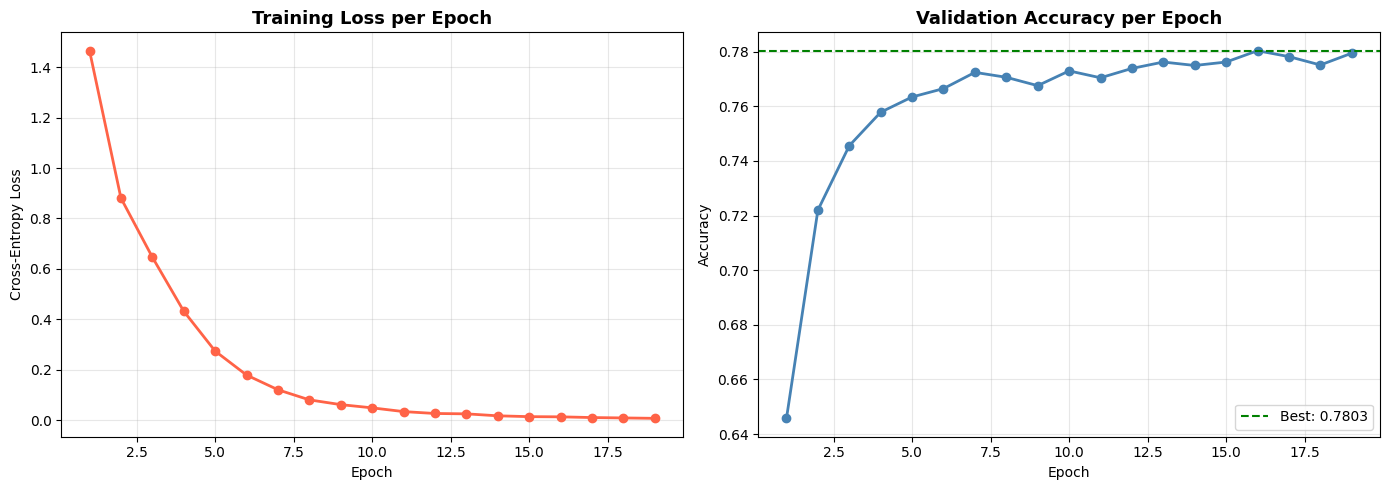

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_ran, history['train_loss'], marker='o', color='tomato', linewidth=2)
axes[0].set_title('Training Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_ran, history['val_acc'], marker='o', color='steelblue', linewidth=2)
axes[1].axhline(best_val_acc, color='green', linestyle='--', linewidth=1.5,
                label=f'Best: {best_val_acc:.4f}')
axes[1].set_title('Validation Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


##  14. Final Evaluation on Test Set


In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.to(device)
test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f" Test Accuracy : {test_acc:.4f}")
print(f"   Best Val Acc  : {best_val_acc:.4f}")


 Test Accuracy : 0.7818
   Best Val Acc  : 0.7803


In [ ]:
print("Classification Report:\n")
print(classification_report(
    test_labels, test_preds,
    target_names=le.classes_
))


Classification Report:
              precision    recall  f1-score   support
       anger       0.81      0.73      0.77       750
        fear       0.82      0.77      0.79       767
         joy       0.76      0.83      0.79      1591
     neutral       0.90      0.94      0.92       735
     sadness       0.73      0.67      0.70       961
    surprise       0.72      0.73      0.72       750
    accuracy                           0.78      5554
   macro avg       0.79      0.78      0.78      5554
weighted avg       0.78      0.78      0.78      5554


##  15. Confusion Matrix


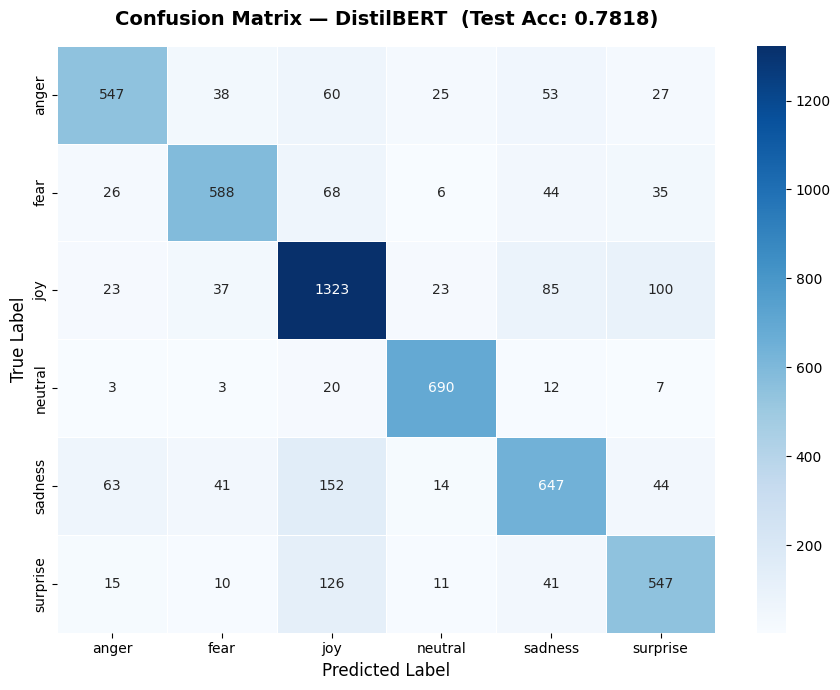

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax, linewidths=0.5
)
ax.set_title(
    f'Confusion Matrix — DistilBERT  (Test Acc: {test_acc:.4f})',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


##  16. Save Results Summary


In [ ]:
summary = {
    'model'         : MODEL_NAME,
    'num_classes'   : NUM_CLASSES,
    'classes'       : le.classes_.tolist(),
    'best_val_acc'  : round(best_val_acc, 4),
    'test_acc'      : round(test_acc, 4),
    'epochs_trained': len(history['train_loss']),
    'train_samples' : len(X_train),
    'val_samples'   : len(X_val),
    'test_samples'  : len(X_test),
}
with open('distilbert_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Results saved to distilbert_results.json")
print(json.dumps(summary, indent=2))


Results saved to distilbert_results.json
{
  "model": "distilbert-base-uncased",
  "num_classes": 6,
  "classes": [
    "anger",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
  ],
  "best_val_acc": 0.7803,
  "test_acc": 0.7818,
  "epochs_trained": 19,
  "train_samples": 25915,
  "val_samples": 5553,
  "test_samples": 5554
}


In [ ]:
from google.colab import files
files.download('best_distilbert.pt')
#

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>